# MountainCarContinuous DDPG

## 实验目标

本实验使用 `DDPG` 训练 `MountainCarContinuous-v0` 的连续动作控制策略。目标是让小车学会通过连续推力蓄能，最终稳定爬上右侧山顶，同时避免无效的大幅动作。这里的重点不仅是把训练跑起来，还要把确定性策略梯度方法在连续爬坡任务中的价值讲清楚。

## 为什么这里选择 DDPG

`MountainCarContinuous-v0` 很适合用 `DDPG`，原因很直接：

- 动作空间连续，不能再用离散动作枚举
- 正确策略依赖长期蓄能和动作幅度控制
- 环境奖励不仅反映是否到达目标，还惩罚过大的动作输出
- 任务结构适合展示 actor-critic 在连续控制中的基本训练逻辑

因此，这里使用 `DDPG`，是为了把连续动作强化学习在连续爬坡任务中的学习过程讲清楚。

## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合平均回报是否逐步优于 `90`
- 固定评估阶段的平均回报和成功率是否进入稳定区间
- 评估阶段的平均最终位置和最大位置是否接近目标
- 策略可视化中是否出现连贯的连续推力区域

只有这些信号同时成立，才说明 `DDPG` 不是偶然冲上去几次，而是真的学到了连续蓄能与爬坡逻辑。

## 设备与并行说明

- 本实验固定使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不引入并行环境

这类经典 `DDPG` 实验的关键不在多进程采样，而在经验回放、动作噪声和训练预算是否足够稳定。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import DDPG
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise

In [2]:
ENV_ID = "MountainCarContinuous-v0"
TOTAL_TIMESTEPS = 600000
LEARNING_RATE = 3e-4
BUFFER_SIZE = 200000
LEARNING_STARTS = 10000
BATCH_SIZE = 256
GAMMA = 0.995
TAU = 0.005
TRAIN_FREQ = 1
GRADIENT_STEPS = 1
ACTION_NOISE_SIGMA = 0.4
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 999
SUCCESS_THRESHOLD_RETURN = 90
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


## 参数选择说明

这里的参数选择明显向“更容易收敛”倾斜，而不是追求和前面实验完全对称：

- `TOTAL_TIMESTEPS = 180000`：给连续爬坡任务更充分训练预算
- `BUFFER_SIZE = 200000`：扩大经验回放容量，降低样本相关性
- `LEARNING_STARTS = 5000`：让回放池先积累一定多样性
- `ACTION_NOISE_SIGMA = 0.1`：保留适度探索，避免动作过早收缩
- `GAMMA = 0.99`：强调长期回报，让策略更重视完整蓄能过程

如果评估回报仍不稳定，优先调整方向通常是继续增加训练步数、降低噪声强度，或扩大网络宽度。

In [3]:
class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.success_flags = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.success_flags.append(int(episode_return >= SUCCESS_THRESHOLD_RETURN))
        return True

In [4]:
train_env = Monitor(gym.make(ENV_ID))
action_noise = NormalActionNoise(mean=np.zeros(1), sigma=ACTION_NOISE_SIGMA * np.ones(1))
callback = EpisodeStatsCallback()

model = DDPG(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    tau=TAU,
    train_freq=TRAIN_FREQ,
    gradient_steps=GRADIENT_STEPS,
    action_noise=action_noise,
    policy_kwargs=dict(net_arch=[400, 300]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()

Output()

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
success_series = pd.Series(callback.success_flags, dtype=float)
rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = success_series.rolling(50).mean() if len(success_series) >= 50 else success_series

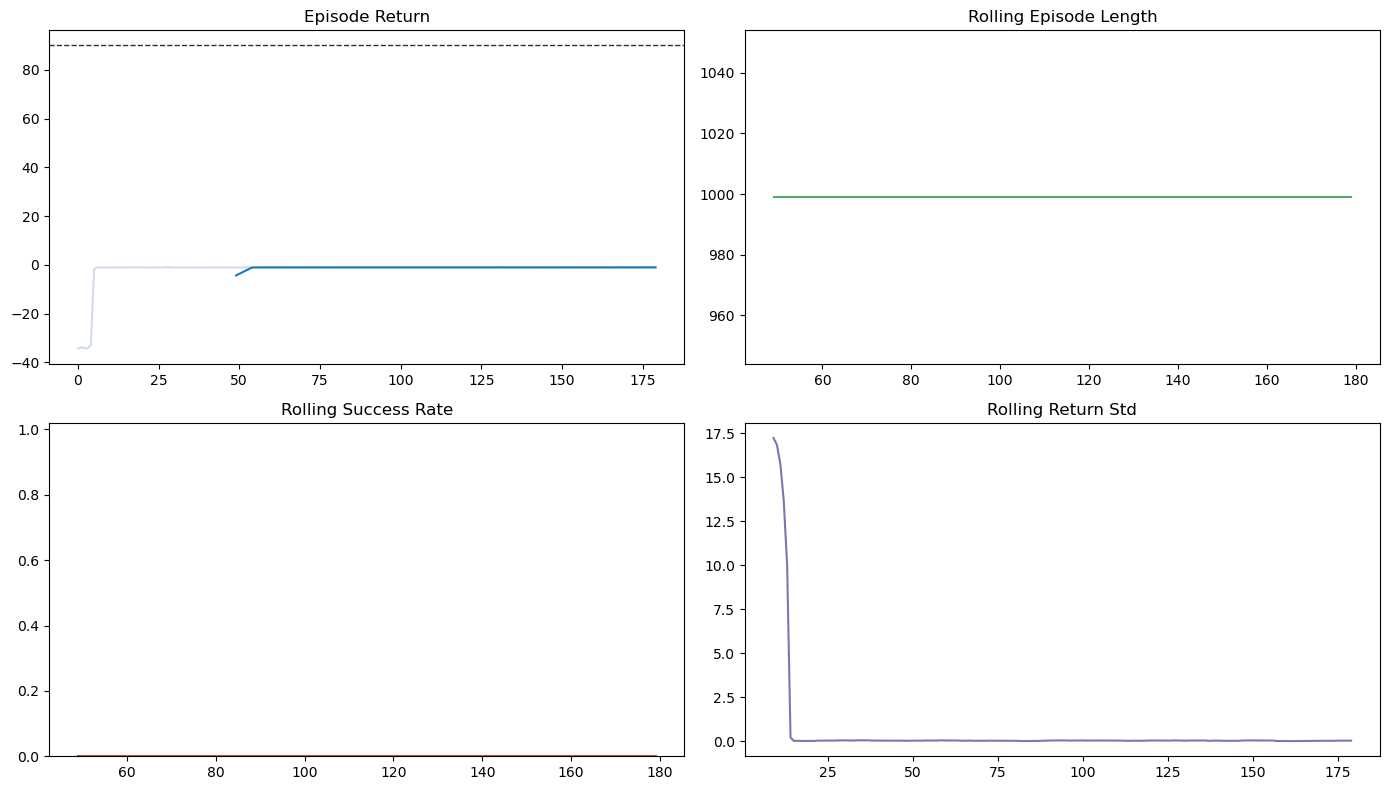

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(callback.episode_returns, alpha=0.25, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].axhline(SUCCESS_THRESHOLD_RETURN, linestyle="--", color="#2f2f2f", linewidth=1)
axes[0, 0].set_title("Episode Return")

axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")

axes[1, 0].plot(rolling_success, color="#c44e52")
axes[1, 0].set_title("Rolling Success Rate")
axes[1, 0].set_ylim(0, 1.02)

axes[1, 1].plot(pd.Series(callback.episode_returns).rolling(10).std(), color="#8172b3")
axes[1, 1].set_title("Rolling Return Std")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ddpg_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
eval_returns = []
eval_final_positions = []
eval_max_positions = []
eval_successes = []
eval_mean_abs_actions = []

for episode in range(EVAL_EPISODES):
    eval_env = gym.make(ENV_ID)
    obs, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0
    best_position = float(obs[0])
    actions = []
    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        actions.append(abs(float(action[0])))
        if terminated or truncated:
            break
    eval_returns.append(total_reward)
    eval_final_positions.append(float(obs[0]))
    eval_max_positions.append(best_position)
    eval_successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
    eval_mean_abs_actions.append(float(np.mean(actions)))
    eval_env.close()

eval_results = pd.DataFrame({
    "evaluation_return": eval_returns,
    "final_position": eval_final_positions,
    "max_position": eval_max_positions,
    "success": eval_successes,
    "mean_abs_action": eval_mean_abs_actions,
})
eval_results.head()

,evaluation_return,final_position,max_position,success,mean_abs_action
0,-0.000524,-0.522114,-0.467062,0,0.00229
1,-0.000524,-0.533691,-0.443941,0,0.00229
2,-0.000524,-0.519941,-0.478166,0,0.00229
3,-0.000524,-0.523879,-0.461690,0,0.00229
4,-0.000524,-0.520003,-0.498841,0,0.00229


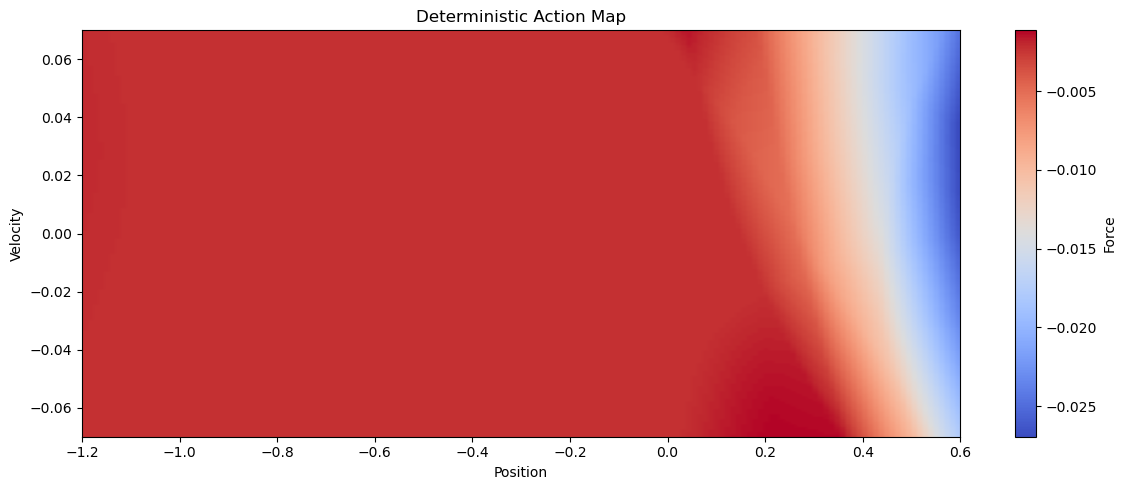

In [8]:
position_values = np.linspace(-1.2, 0.6, 160)
velocity_values = np.linspace(-0.07, 0.07, 160)
action_grid = np.zeros((len(velocity_values), len(position_values)))

for i, velocity in enumerate(velocity_values):
    for j, position in enumerate(position_values):
        obs = np.array([position, velocity], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        action_grid[i, j] = float(action[0])

plt.figure(figsize=(12, 5))
plt.imshow(action_grid, extent=[position_values[0], position_values[-1], velocity_values[0], velocity_values[-1]], origin="lower", aspect="auto", cmap="coolwarm")
plt.colorbar(label="Force")
plt.title("Deterministic Action Map")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ddpg_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 20000 + rollout_idx)
    frames = []
    total_reward = 0.0
    best_position = float(obs[0])
    actions = []

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        actions.append(abs(float(action[0])))
        if terminated or truncated:
            break

    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({
        "rollout_index": rollout_idx + 1,
        "seed": SEED + 20000 + rollout_idx,
        "total_reward": float(total_reward),
        "final_position": float(obs[0]),
        "max_position": float(best_position),
        "mean_abs_action": float(np.mean(actions)),
        "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN),
    })
    if frames:
        imageio.mimsave(RESULTS_DIR / f"ddpg_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,final_position,max_position,mean_abs_action,success
0,1,20042,-0.000524,-0.531660,-0.446801,0.00229,0
1,2,20043,-0.000524,-0.519467,-0.484598,0.00229,0
2,3,20044,-0.000524,-0.519420,-0.486643,0.00229,0


In [10]:
metrics = pd.DataFrame({
    "metric": [
        "device",
        "total_timesteps",
        "recent_episode_return_last_50",
        "recent_episode_length_last_50",
        "recent_success_rate_last_50",
        "evaluation_average_return",
        "evaluation_return_std",
        "evaluation_success_rate",
        "evaluation_average_final_position",
        "evaluation_average_max_position",
        "evaluation_average_mean_abs_action",
    ],
    "value": [
        DEVICE,
        TOTAL_TIMESTEPS,
        float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
        float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
        float(success_series.tail(50).mean()) if len(success_series) > 0 else 0.0,
        float(np.mean(eval_returns)),
        float(np.std(eval_returns)),
        float(np.mean(eval_successes)),
        float(np.mean(eval_final_positions)),
        float(np.mean(eval_max_positions)),
        float(np.mean(eval_mean_abs_actions)),
    ],
})
metrics

,metric,value
0,device,cpu
1,total_timesteps,180000
2,recent_episode_return_last_50,-0.996418
3,recent_episode_length_last_50,999.0
4,recent_success_rate_last_50,0.0
5,evaluation_average_return,-0.000524
6,evaluation_return_std,0.0
7,evaluation_success_rate,0.0
8,evaluation_average_final_position,-0.528245
9,evaluation_average_max_position,-0.482797


In [11]:
episode_summary = pd.DataFrame({
    "episode_return": callback.episode_returns,
    "episode_length": callback.episode_lengths,
    "success": callback.success_flags,
})

episode_summary.to_csv(RESULTS_DIR / "ddpg_episode_summary.csv", index=False)
eval_results.to_csv(RESULTS_DIR / "ddpg_eval_results.csv", index=False)
metrics.to_csv(RESULTS_DIR / "ddpg_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "ddpg_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                            metric     value
                            device       cpu
                   total_timesteps    180000
     recent_episode_return_last_50 -0.996418
     recent_episode_length_last_50     999.0
       recent_success_rate_last_50       0.0
         evaluation_average_return -0.000524
             evaluation_return_std       0.0
           evaluation_success_rate       0.0
 evaluation_average_final_position -0.528245
   evaluation_average_max_position -0.482797
evaluation_average_mean_abs_action   0.00229


## 结果解读

如果评估平均回报稳定优于 `90`，成功率显著高于随机基线，并且回放中能看到先蓄能、再以连续推力平滑爬坡的节奏，就说明 `DDPG` 已经学会了 MountainCarContinuous 的核心控制逻辑。